## 1. Imports & Setup

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')


# Clean aesthetic
sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'No': '#4C9BE8', 'Yes': '#E8704C'}

print('Libraries loaded.')

Libraries loaded.


## 2. Load Data

In [2]:
df_raw = pd.read_csv(r'/Users/aloksingh/Documents/Churn_analysis/data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = df_raw.copy()

print(f'Shape: {df.shape}  ({df.shape[0]:,} rows × {df.shape[1]} columns)')
df.head(3)

Shape: (7043, 21)  (7,043 rows × 21 columns)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 3. Data Types & Schema Audit

In [3]:
schema = pd.DataFrame({
    'dtype':       df.dtypes,
    'nunique':     df.nunique(),
    'sample':      df.iloc[0]
})
print(schema.to_string())

                    dtype  nunique            sample
customerID         object     7043        7590-VHVEG
gender             object        2            Female
SeniorCitizen       int64        2                 0
Partner            object        2               Yes
Dependents         object        2                No
tenure              int64       73                 1
PhoneService       object        2                No
MultipleLines      object        3  No phone service
InternetService    object        3               DSL
OnlineSecurity     object        3                No
OnlineBackup       object        3               Yes
DeviceProtection   object        3                No
TechSupport        object        3                No
StreamingTV        object        3                No
StreamingMovies    object        3                No
Contract           object        3    Month-to-month
PaperlessBilling   object        2               Yes
PaymentMethod      object        4  Electronic

In [4]:
# ── Flag: TotalCharges is stored as string, not float ─────────────────────
print('TotalCharges dtype:  ', df['TotalCharges'].dtype)
print('Sample values:       ', df['TotalCharges'].head(5).tolist())

# Convert and count hidden NaNs (whitespace-only cells)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_missing = df['TotalCharges'].isna().sum()
print(f'\nAfter pd.to_numeric: {n_missing} NaNs found (were whitespace strings)')

TotalCharges dtype:   object
Sample values:        ['29.85', '1889.5', '108.15', '1840.75', '151.65']

After pd.to_numeric: 11 NaNs found (were whitespace strings)


In [5]:
# ── Inspect those 11 problematic rows ─────────────────────────────────────
bad = df[df['TotalCharges'].isna()][['customerID','tenure','MonthlyCharges','TotalCharges','Churn']]
print(f'All {len(bad)} rows with blank TotalCharges have tenure = 0 (brand new customers):')
bad

All 11 rows with blank TotalCharges have tenure = 0 (brand new customers):


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [6]:
# ── Decision: fill with 0.0 (tenure=0 → no charges yet, not random) ───────
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
print('TotalCharges NaNs remaining:', df['TotalCharges'].isna().sum())

TotalCharges NaNs remaining: 0


## 4. Missing Values 

In [7]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'None — dataset is clean after TotalCharges fix.')

Missing values per column:
None — dataset is clean after TotalCharges fix.


## 5. Target Variable — Class Imbalance Analysis

In [9]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('=== Target Distribution ===')
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2)}))
print(f'\nImbalance ratio — No:Yes = {churn_counts["No"]/churn_counts["Yes"]:.2f}:1')


=== Target Distribution ===
       Count  Percentage
Churn                   
No      5174       73.46
Yes     1869       26.54

Imbalance ratio — No:Yes = 2.77:1


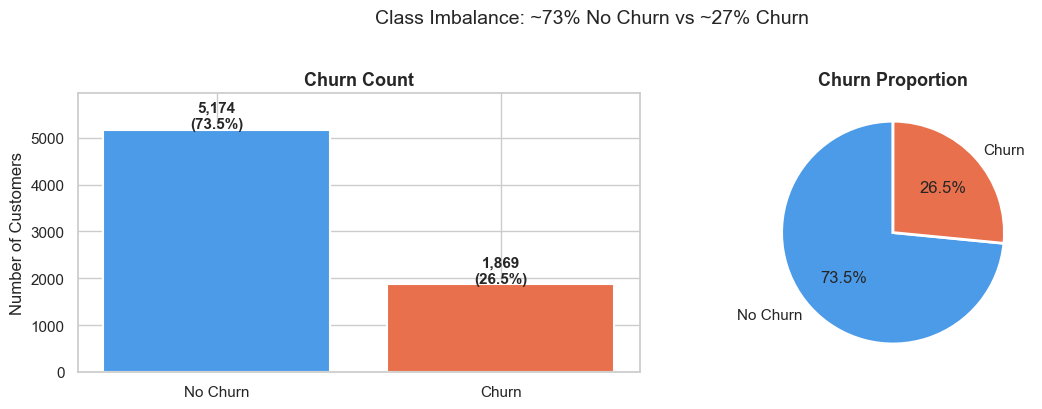


⚠️  IMBALANCE HANDLING STRATEGY:
  - Simple Accuracy is misleading: predicting 'No' for all gives 73.5% accuracy
  - We will use: SMOTE (inside Pipeline) + scale_pos_weight in XGBoost
  - Evaluation metrics: ROC-AUC, F1 (churn class), Precision-Recall AUC


In [11]:
ig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['No Churn', 'Churn'], churn_counts.values,
            color=[COLORS['No'], COLORS['Yes']], edgecolor='white', linewidth=1.5)
for i, (v, p) in enumerate(zip(churn_counts.values, churn_pct.values)):
    axes[0].text(i, v + 30, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Churn Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, churn_counts.max() * 1.15)

# Pie chart
axes[1].pie(churn_counts.values, labels=['No Churn', 'Churn'],
            colors=[COLORS['No'], COLORS['Yes']],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Class Imbalance: ~73% No Churn vs ~27% Churn', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n⚠️  IMBALANCE HANDLING STRATEGY:")
print("  - Simple Accuracy is misleading: predicting 'No' for all gives 73.5% accuracy")
print("  - We will use: SMOTE (inside Pipeline) + scale_pos_weight in XGBoost")
print("  - Evaluation metrics: ROC-AUC, F1 (churn class), Precision-Recall AUC")

## 6. Numeric Feature Distributions

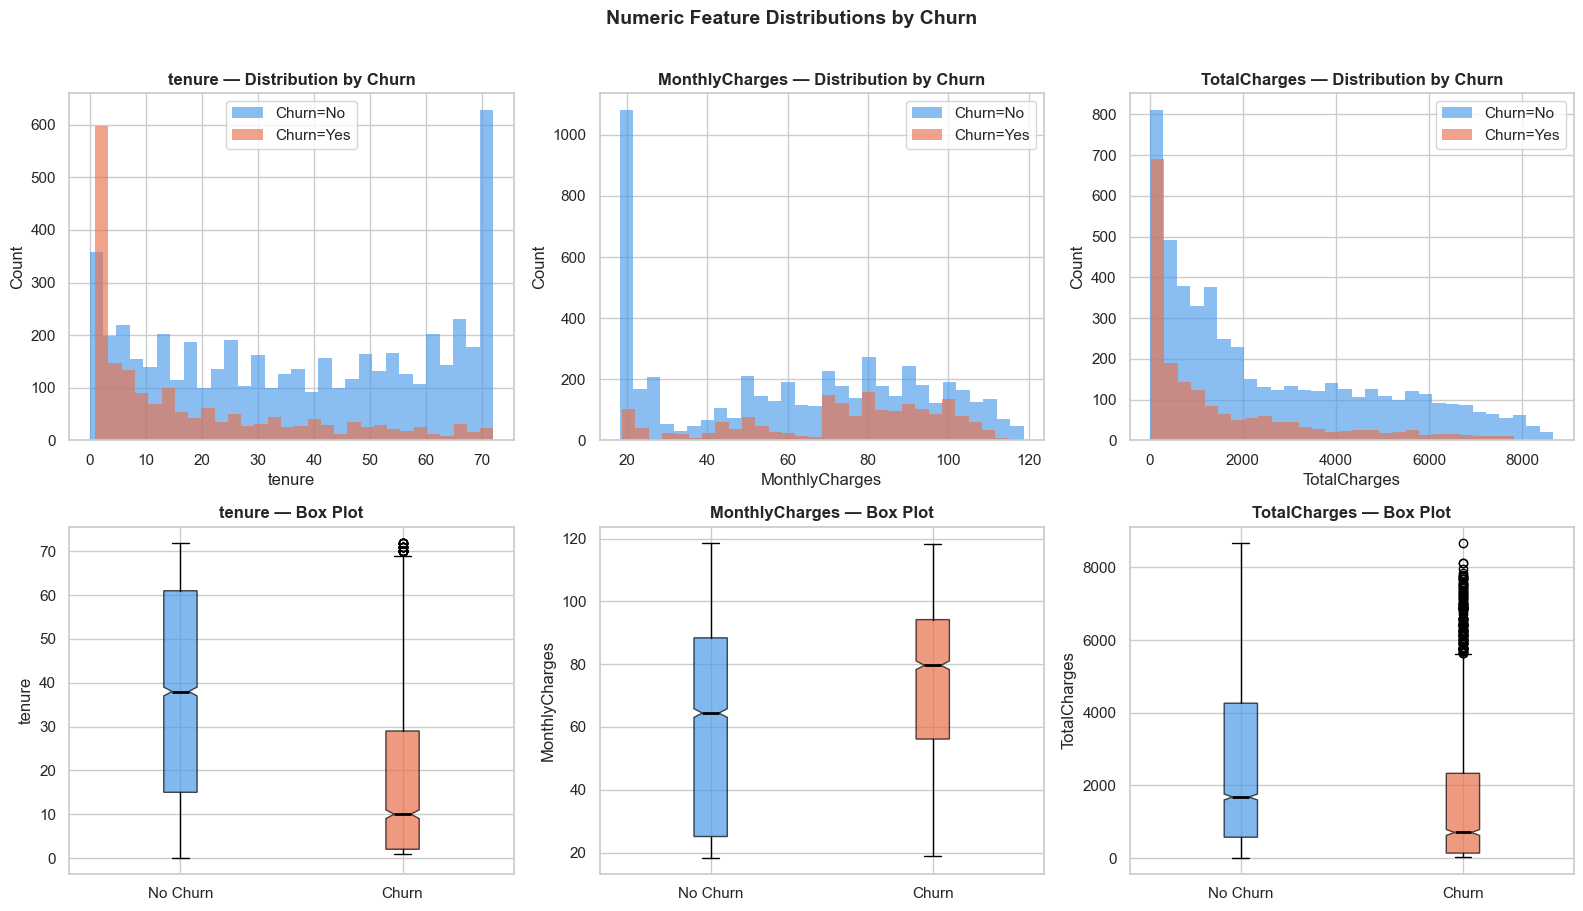


Key observations:
  tenure:         Churners heavily skew toward short tenure (0-12 months)
  MonthlyCharges: Churners have higher monthly charges on average
  TotalCharges:   Churners have lower total charges (correlated with short tenure)


In [12]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, col in enumerate(numeric_cols):
    # Top row: histogram split by churn
    for churn_val, color in COLORS.items():
        subset = df[df['Churn'] == churn_val][col]
        axes[0, i].hist(subset, bins=30, alpha=0.65, color=color,
                        label=f'Churn={churn_val}', edgecolor='none')
    axes[0, i].set_title(f'{col} — Distribution by Churn', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')
    axes[0, i].legend()

    # Bottom row: box plot by churn
    data_no  = df[df['Churn'] == 'No'][col]
    data_yes = df[df['Churn'] == 'Yes'][col]
    bp = axes[1, i].boxplot([data_no, data_yes], labels=['No Churn', 'Churn'],
                             patch_artist=True, notch=True,
                             medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor(COLORS['No'])
    bp['boxes'][1].set_facecolor(COLORS['Yes'])
    for box in bp['boxes']:
        box.set_alpha(0.7)
    axes[1, i].set_title(f'{col} — Box Plot', fontweight='bold')
    axes[1, i].set_ylabel(col)

plt.suptitle('Numeric Feature Distributions by Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nKey observations:')
print('  tenure:         Churners heavily skew toward short tenure (0-12 months)')
print('  MonthlyCharges: Churners have higher monthly charges on average')
print('  TotalCharges:   Churners have lower total charges (correlated with short tenure)')

## 7. Categorical Feature Analysis

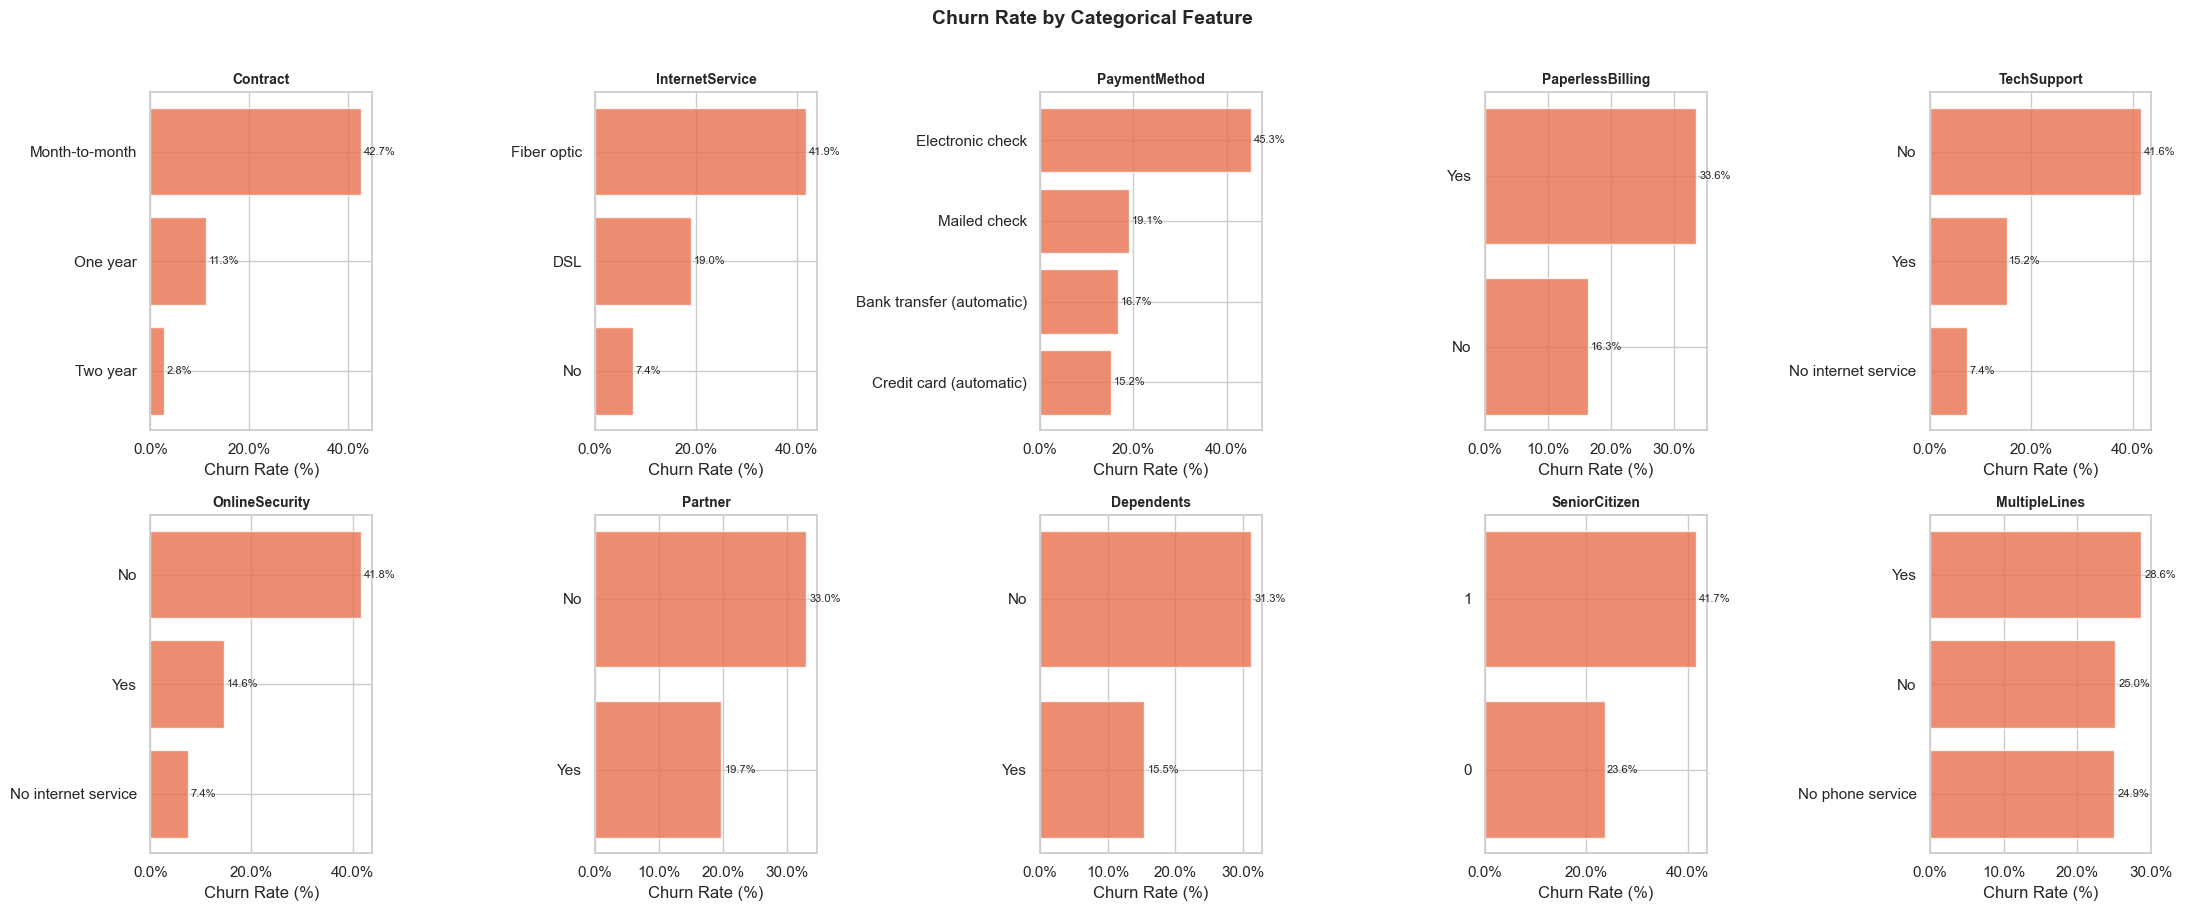

In [13]:
# ── Churn rate per categorical feature ────────────────────────────────────
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling',
            'TechSupport', 'OnlineSecurity', 'Partner', 'Dependents',
            'SeniorCitizen', 'MultipleLines']

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn_bin'].mean().sort_values(ascending=True)
    bars = axes[i].barh(churn_rate.index.astype(str), churn_rate.values * 100,
                        color='#E8704C', alpha=0.8, edgecolor='white')
    axes[i].set_xlabel('Churn Rate (%)')
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].xaxis.set_major_formatter(mtick.PercentFormatter())
    # Add value labels
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(val * 100 + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val*100:.1f}%', va='center', fontsize=8)

plt.suptitle('Churn Rate by Categorical Feature', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# ── Print churn rates as a clean table ────────────────────────────────────
print('\n=== TOP CHURN RATE SEGMENTS ===')
high_risk = [
    ('Contract',          'Month-to-month', df[df['Contract']=='Month-to-month']['Churn_bin'].mean()),
    ('InternetService',   'Fiber optic',    df[df['InternetService']=='Fiber optic']['Churn_bin'].mean()),
    ('PaymentMethod',     'Electronic check',df[df['PaymentMethod']=='Electronic check']['Churn_bin'].mean()),
    ('PaperlessBilling',  'Yes',            df[df['PaperlessBilling']=='Yes']['Churn_bin'].mean()),
    ('TechSupport',       'No',             df[df['TechSupport']=='No']['Churn_bin'].mean()),
    ('OnlineSecurity',    'No',             df[df['OnlineSecurity']=='No']['Churn_bin'].mean()),
    ('SeniorCitizen',     '1',              df[df['SeniorCitizen']==1]['Churn_bin'].mean()),
]
for feat, val, rate in sorted(high_risk, key=lambda x: -x[2]):
    print(f'  {feat:20s} = {str(val):20s} → {rate*100:.1f}% churn')


=== TOP CHURN RATE SEGMENTS ===
  PaymentMethod        = Electronic check     → 45.3% churn
  Contract             = Month-to-month       → 42.7% churn
  InternetService      = Fiber optic          → 41.9% churn
  OnlineSecurity       = No                   → 41.8% churn
  SeniorCitizen        = 1                    → 41.7% churn
  TechSupport          = No                   → 41.6% churn
  PaperlessBilling     = Yes                  → 33.6% churn


## 8. Tenure Analysis — Churn Over Customer Lifetime

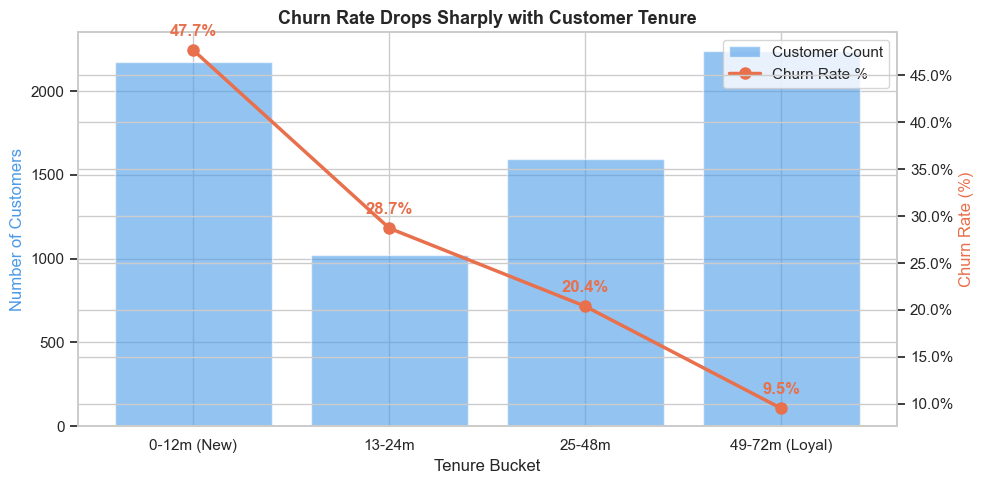


Insight: Nearly 50% of customers in their first year churn.
Loyal customers (49-72m) churn at only 9.5% — tenure is the #1 risk indicator.


In [15]:
df['tenure_bucket'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12m (New)', '13-24m', '25-48m', '49-72m (Loyal)']
)

tenure_churn = df.groupby('tenure_bucket', observed=True).agg(
    count=('Churn_bin', 'count'),
    churn_rate=('Churn_bin', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

bars = ax1.bar(tenure_churn['tenure_bucket'].astype(str),
               tenure_churn['count'], color='#4C9BE8', alpha=0.6, label='Customer Count')
line = ax2.plot(tenure_churn['tenure_bucket'].astype(str),
                tenure_churn['churn_rate'] * 100, 'o-',
                color='#E8704C', linewidth=2.5, markersize=8, label='Churn Rate %')

for i, (rate, count) in enumerate(zip(tenure_churn['churn_rate'], tenure_churn['count'])):
    ax2.annotate(f'{rate*100:.1f}%', (i, rate*100),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontweight='bold', color='#E8704C')

ax1.set_ylabel('Number of Customers', color='#4C9BE8')
ax2.set_ylabel('Churn Rate (%)', color='#E8704C')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_xlabel('Tenure Bucket')
plt.title('Churn Rate Drops Sharply with Customer Tenure', fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

print('\nInsight: Nearly 50% of customers in their first year churn.')
print('Loyal customers (49-72m) churn at only 9.5% — tenure is the #1 risk indicator.')

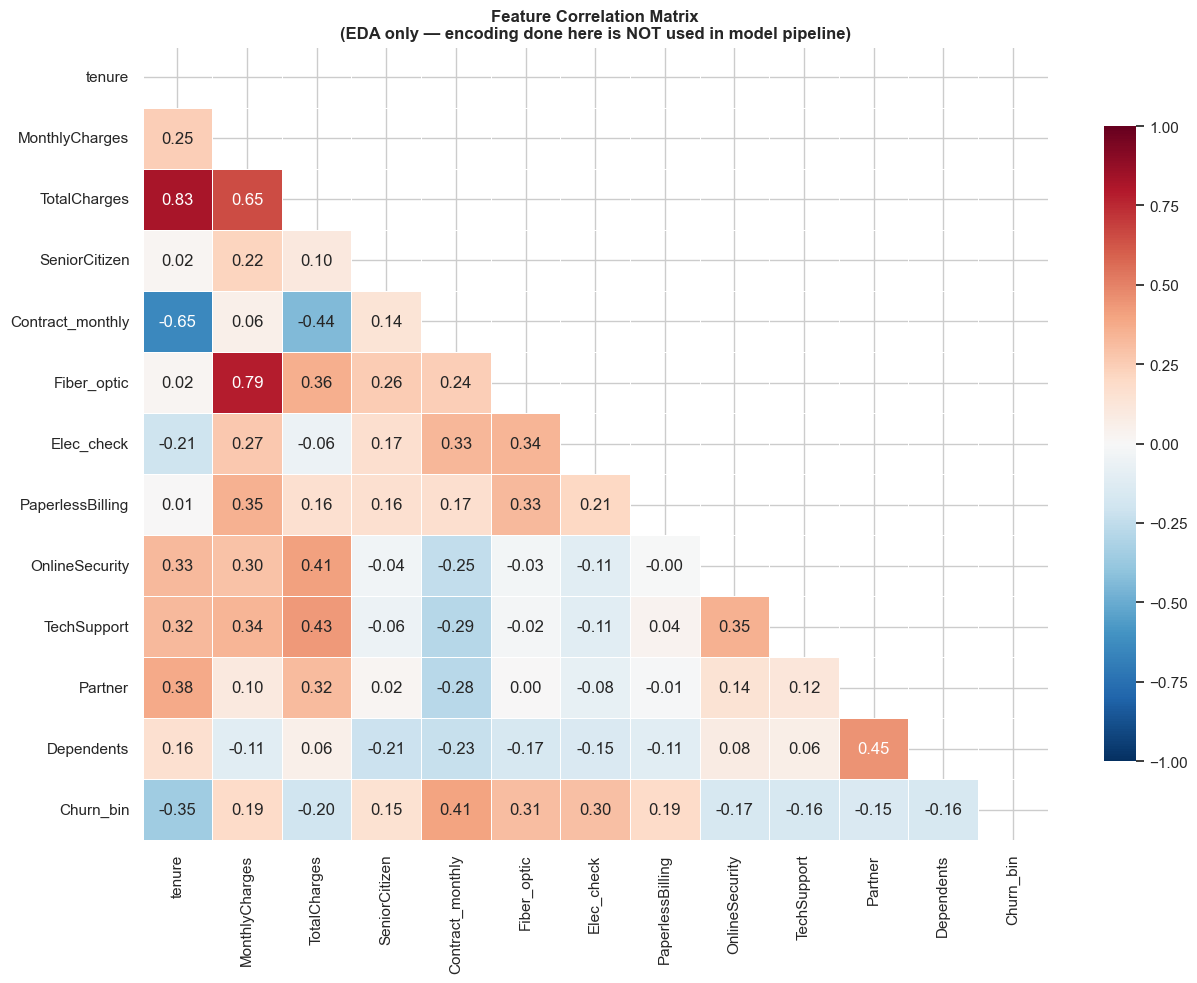


Correlation with Churn (sorted):
  tenure                 -0.352  ███████
  TotalCharges           -0.198  ███
  OnlineSecurity         -0.171  ███
  TechSupport            -0.165  ███
  Dependents             -0.164  ███
  Partner                -0.150  ███
  SeniorCitizen          +0.151  ███
  PaperlessBilling       +0.192  ███
  MonthlyCharges         +0.193  ███
  Elec_check             +0.302  ██████
  Fiber_optic            +0.308  ██████
  Contract_monthly       +0.405  ████████


In [ ]:

df_corr = df.copy()
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling',
               'OnlineSecurity','OnlineBackup','DeviceProtection',
               'TechSupport','StreamingTV','StreamingMovies']
for col in binary_cols:
    df_corr[col] = df_corr[col].map({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})

df_corr['gender_M']         = (df_corr['gender'] == 'Male').astype(int)
df_corr['Contract_monthly'] = (df_corr['Contract'] == 'Month-to-month').astype(int)
df_corr['Fiber_optic']      = (df_corr['InternetService'] == 'Fiber optic').astype(int)
df_corr['Elec_check']       = (df_corr['PaymentMethod'] == 'Electronic check').astype(int)

corr_cols = ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen',
             'Contract_monthly','Fiber_optic','Elec_check','PaperlessBilling',
             'OnlineSecurity','TechSupport','Partner','Dependents','Churn_bin']

corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix\n(EDA only — encoding done here is NOT used in model pipeline)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelation with Churn (sorted):')
churn_corr = corr_matrix['Churn_bin'].drop('Churn_bin').sort_values()
for feat, val in churn_corr.items():
    bar = '█' * int(abs(val) * 20)
    sign = '+' if val > 0 else '-'
    print(f'  {feat:22s} {sign}{abs(val):.3f}  {bar}')

In [ ]:

df_fe = df.copy()

# 1. Avg monthly charge rate (handles tenure=0 edge case)
df_fe['AvgMonthlyCharge'] = df_fe.apply(
    lambda r: r['TotalCharges'] / r['tenure'] if r['tenure'] > 0 else r['MonthlyCharges'], axis=1
)

# 2. Service bundle count (0–6)
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']
df_fe['ServiceCount'] = sum(
    (df_fe[col] == 'Yes').astype(int) for col in service_cols
)

# 3. High risk flag
df_fe['HighRisk'] = (
    (df_fe['Contract'] == 'Month-to-month') &
    (df_fe['tenure'] < 12) &
    (df_fe['PaymentMethod'] == 'Electronic check')
).astype(int)

print('=== ENGINEERED FEATURE VALIDATION ===')
print('\nAvgMonthlyCharge — churn vs no-churn median:')
print(df_fe.groupby('Churn')['AvgMonthlyCharge'].median())

print('\nServiceCount — churn rate by count:')
print(df_fe.groupby('ServiceCount')['Churn_bin'].mean().round(3))

print('\nHighRisk flag — churn rate:')
print(df_fe.groupby('HighRisk')['Churn_bin'].mean().round(3))
print(f'\nHighRisk=1 captures {df_fe["HighRisk"].sum()} customers with {df_fe[df_fe["HighRisk"]==1]["Churn_bin"].mean()*100:.1f}% churn rate')

=== ENGINEERED FEATURE VALIDATION ===

AvgMonthlyCharge — churn vs no-churn median:
Churn
No     63.978909
Yes    79.312500
Name: AvgMonthlyCharge, dtype: float64

ServiceCount — churn rate by count:
ServiceCount
0    0.214
1    0.458
2    0.358
3    0.274
4    0.223
5    0.124
6    0.053
Name: Churn_bin, dtype: float64

HighRisk flag — churn rate:
HighRisk
0    0.209
1    0.639
Name: Churn_bin, dtype: float64

HighRisk=1 captures 917 customers with 63.9% churn rate
